# Environment setting

In [4]:
import tempfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scvi
import seaborn as sns
import torch
from cell2location.models import Cell2location, RegressionModel
from cell2location.plt import plot_spatial
from cell2location.utils import select_slide
from cell2location.utils.filtering import filter_genes
scvi.settings.seed = 0

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 0


In [5]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Single cell reference

In [2]:
import scanpy as sc
import numpy as np

total_data = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/After_QC_Before_HVG_raw.h5ad")
lymphoid = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Lymphoid_subtype_raw.h5ad")
module = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/modeling_luminal.h5ad")

total_data.obs["annotation"] = np.nan

cd8 = lymphoid.obs_names[lymphoid.obs["subtype"] == "CD8_T_cells"]
common_cd8 = total_data.obs_names.intersection(cd8)
total_data.obs.loc[common_cd8, "annotation"] = "CD8_T_cells"
common_module = total_data.obs_names.intersection(module.obs_names)
total_data.obs.loc[common_module, "annotation"] = module.obs.loc[
    common_module, "module_cluster"
]

total_data = total_data[~total_data.obs["annotation"].isna()].copy()

/tmp/ipykernel_24232/1880560831.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CD8_T_cells' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  total_data.obs.loc[common_cd8, "annotation"] = "CD8_T_cells"


In [6]:
total_data.obs["predictions"] = total_data.obs["annotation"]

In [7]:
import os
import scanpy as sc
outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation"
os.makedirs(outdir, exist_ok=True)

total_data.write(f"{outdir}/sc_reference(raw).h5ad")

# Cell2loacation (reference)

In [6]:
import scanpy as sc
adata_ref = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/sc_reference_raw.h5ad")

In [7]:
adata_ref.var["SYMBOL"] = adata_ref.var_names.astype(str)
adata_ref.var_names_make_unique()
del adata_ref.raw

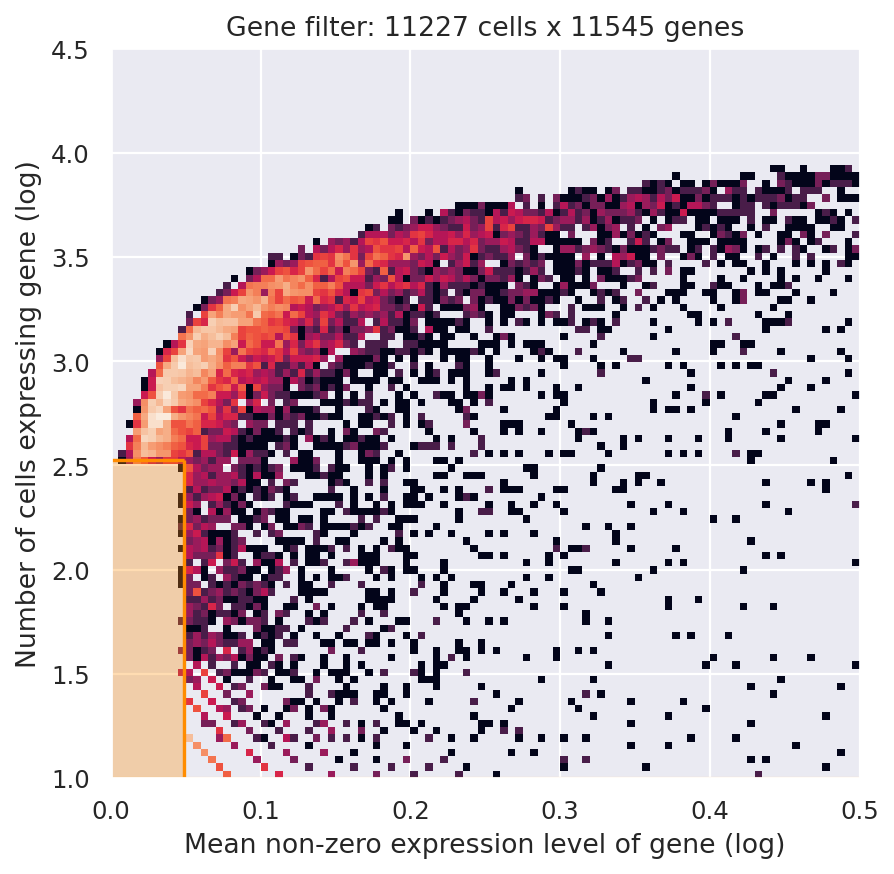

In [9]:
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)
adata_ref = adata_ref[:, selected].copy()

In [10]:
RegressionModel.setup_anndata(adata=adata_ref,batch_key="sample_id", labels_key="annotation")
mod = RegressionModel(adata_ref)
mod.view_anndata_setup()

mod.train(
    max_epochs=250,
    batch_size=2500,
    train_size=1,
    lr=0.002)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Anndata setup with scvi-tools version 1.1.6.post2.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample_id',
│   'labels_key': 'annotation',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  40   │
│         n_cells          │ 11227 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   4   │
│          n_vars          │ 11545 │
└──────────────────────────┴───────┘

...

                     labels State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['annotation'] │ CD8_T_cells │          0          │
│                         │   module2   │          1          │
│                         │   module7   │          2          │
│                         │   module8   │          3          │
└─────────────────────────┴─────────────┴─────────────────────┘

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib

Epoch 250/250: 100%|██████████| 250/250 [02:48<00:00,  1.48it/s, v_num=1, elbo_train=6.5e+7] 

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [02:48<00:00,  1.48it/s, v_num=1, elbo_train=6.5e+7]


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling global variables, sample: 100%|██████████| 999/999 [00:09<00:00, 108.24it/s]


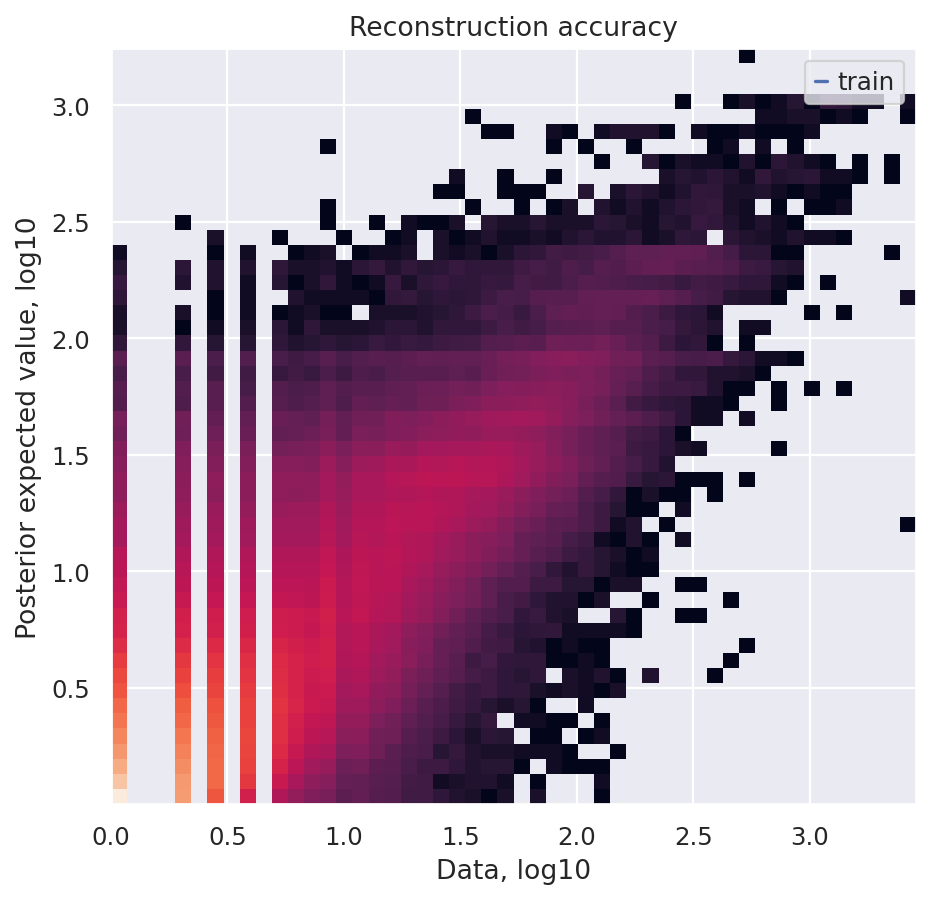

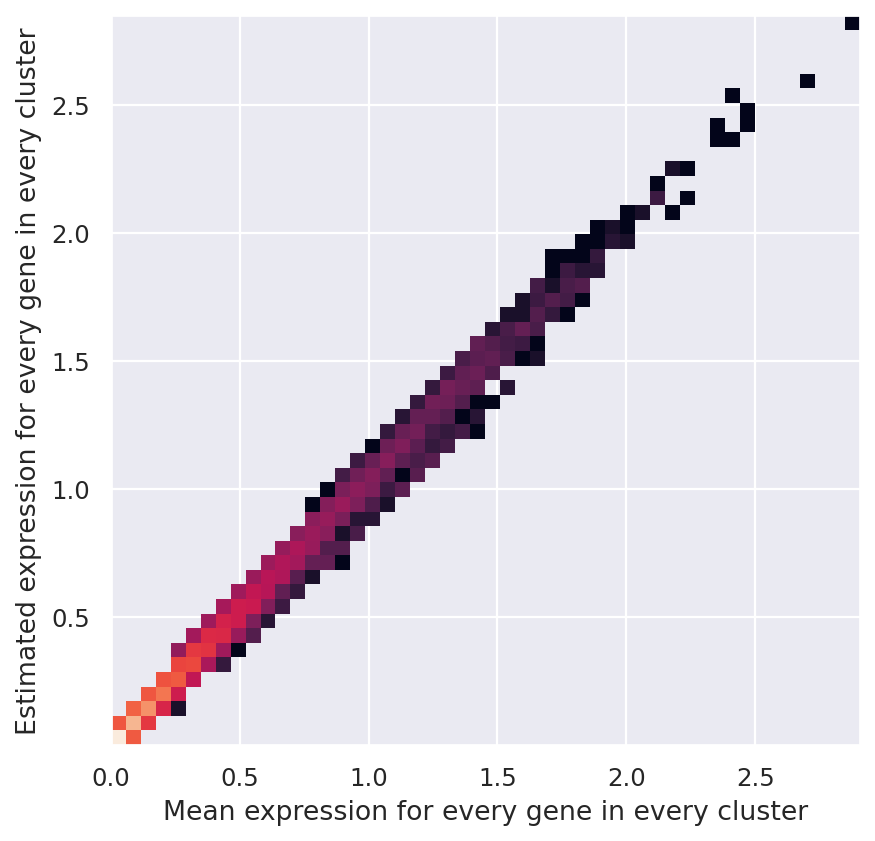

In [11]:
mod.plot_history(20)
adata_ref = mod.export_posterior(adata_ref,sample_kwargs={"num_samples": 1000, "batch_size": 2500},)
mod.plot_QC()

In [12]:
if "means_per_cluster_mu_fg" in adata_ref.varm.keys():
    inf_aver = adata_ref.varm["means_per_cluster_mu_fg"][
        [f"means_per_cluster_mu_fg_{i}" for i in adata_ref.uns["mod"]["factor_names"]]
    ].copy()
else:
    inf_aver = adata_ref.var[
        [f"means_per_cluster_mu_fg_{i}" for i in adata_ref.uns["mod"]["factor_names"]]
    ].copy()
inf_aver.columns = adata_ref.uns["mod"]["factor_names"]
inf_aver.iloc[0:5, 0:5]

,CD8_T_cells,module2,module7,module8
gene_name,,,,
Rp1,0.000251,0.001388,0.000429,0.020295
Sox17,0.000252,1.501415,0.460749,0.591448
Mrpl15,0.228596,0.415307,0.641382,0.233920
Lypla1,0.137919,0.336599,0.162033,0.076277
Tcea1,0.494503,1.573020,0.542141,0.508382


In [13]:
import os

base_dir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation"
model_dir = f"{base_dir}/model"
sc_dir = f"{base_dir}/sc_reference_preprocess"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(sc_dir, exist_ok=True)
mod.save(model_dir, overwrite=True)
adata_ref.write(f"{sc_dir}/sc.h5ad")

# Total sample

In [128]:
import scanpy as sc
adata_vis = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Save_data/merge_visium/merged_visium.h5ad")

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [129]:
adata_vis.var["SYMBOL"] = adata_vis.var_names
adata_vis.var_names_make_unique()

In [130]:
adata_vis.var["SYMBOL"] = adata_vis.var_names
#adata_vis.var.set_index("gene_ids", drop=True, inplace=True)
adata_vis.var["MT_gene"] = [gene.startswith("MT-") for gene in adata_vis.var["SYMBOL"]]
adata_vis.obsm["MT"] = adata_vis[:, adata_vis.var["MT_gene"].values].X.toarray()
adata_vis = adata_vis[:, ~adata_vis.var["MT_gene"].values]

In [131]:
adata_vis.var_names = adata_vis.var["SYMBOL"]
adata_vis.var_names_make_unique()

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Anndata setup with scvi-tools version 1.1.6.post2.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample_id',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  16   │
│         n_cells          │ 16934 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 11365 │
└──────────────────────────┴───────┘

...

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/lightning/pytorch/trainer/conn

Epoch 3000/3000: 100%|██████████| 3000/3000 [12:46<00:00,  3.70it/s, v_num=1, elbo_train=1.09e+8]

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 3000/3000: 100%|██████████| 3000/3000 [12:46<00:00,  3.91it/s, v_num=1, elbo_train=1.09e+8]


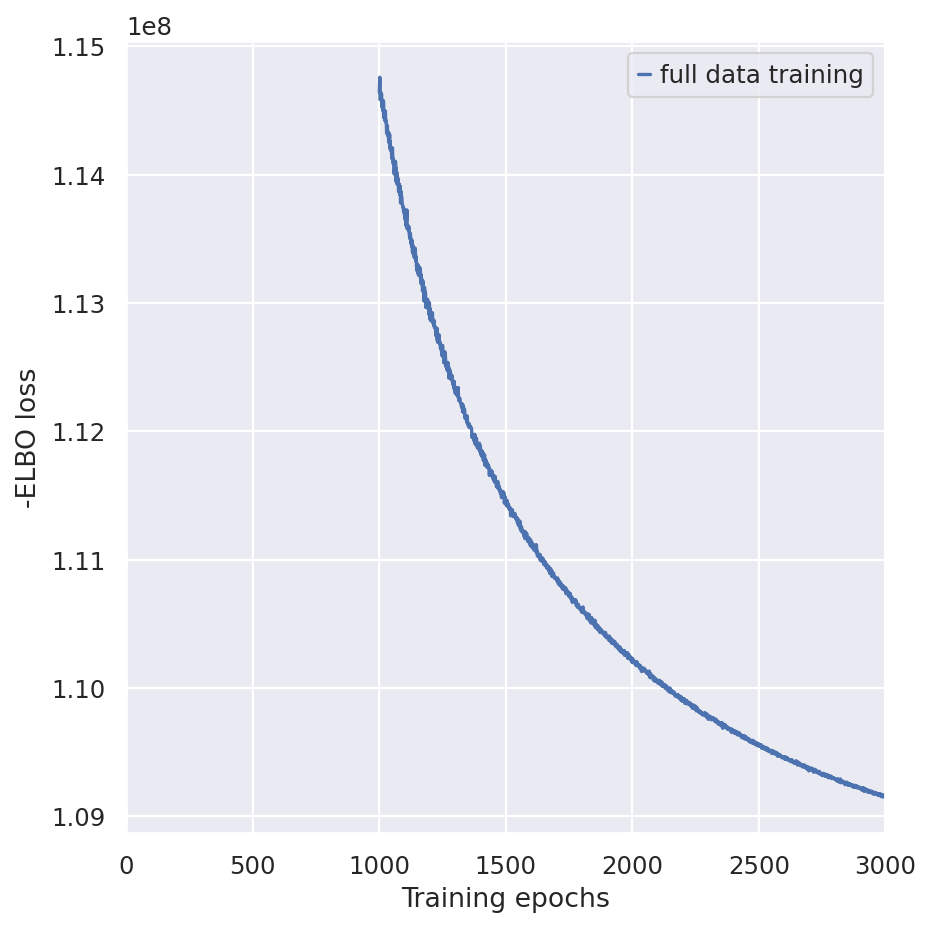

In [132]:
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

Cell2location.setup_anndata(adata_vis, batch_key="sample_id")

mod = Cell2location(
    adata_vis,
    cell_state_df=inf_aver,
    N_cells_per_location=30,
    detection_alpha=200,)
mod.view_anndata_setup()
mod.train(
    max_epochs=3000,
    batch_size=None,
    train_size=1
)
mod.plot_history(1000)
plt.legend(labels=["full data training"]);

In [133]:
import pandas as pd
adata_vis.obs_names = (adata_vis.obs["sample_id"].astype(str) + "_" + adata_vis.obs_names.astype(str))
adata_vis.obs_names_make_unique()
adata_vis.obs['sample_id'] = adata_vis.obs['sample_id'].astype(str)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling global variables, sample: 100%|██████████| 999/999 [00:32<00:00, 30.67it/s]


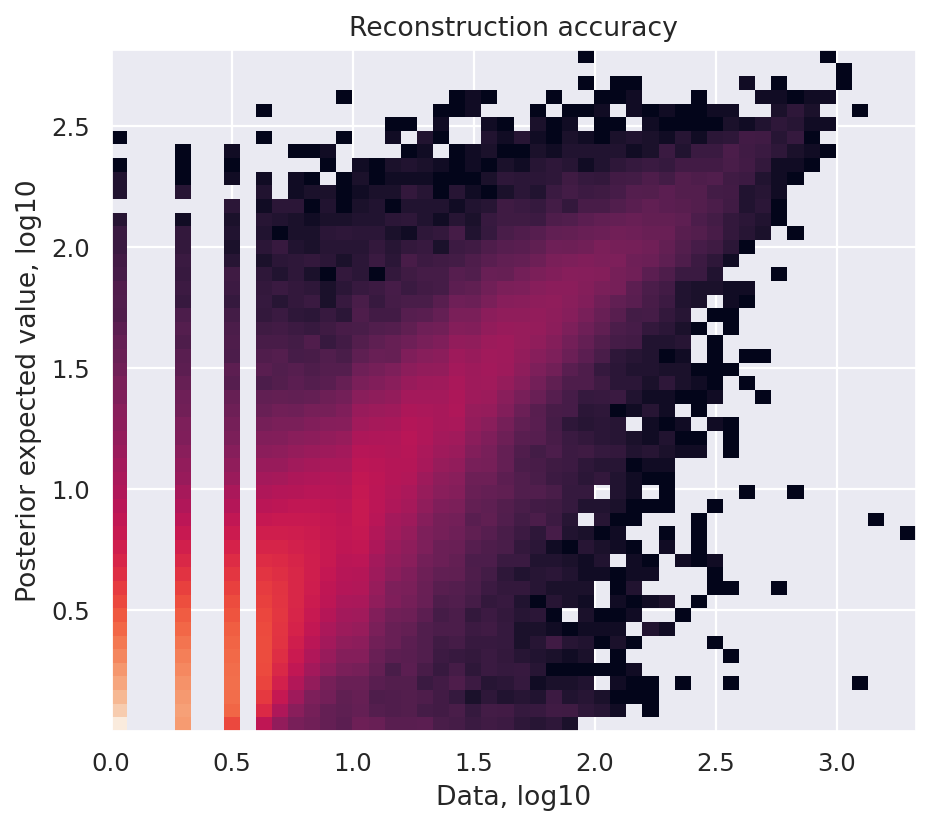

In [135]:
adata_vis = mod.export_posterior(adata_vis,sample_kwargs={"num_samples": 1000, "batch_size": mod.adata.n_obs},)
mod.plot_QC()
#fig = mod.plot_spatial_QC_across_batches()

In [138]:
adata_vis.write_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad")

# Data split

In [127]:
import scanpy as sc
import os
import numpy as np

in_h5ad = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/merged_visium_decon.h5ad"
outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation/"

adata = sc.read_h5ad(in_h5ad)

os.makedirs(outdir, exist_ok=True)

for sid in adata.obs["sample_id"].unique():
    ad = adata[adata.obs["sample_id"] == sid].copy()

    if "spatial" not in ad.uns:
        ad.uns["spatial"] = {
            sid: {
                "images": {},
                "scalefactors": {},
                "metadata": {}
            }
        }

    if "spatial" in ad.obsm:
        ad.obsm["spatial"] = np.asarray(ad.obsm["spatial"])

    out_path = os.path.join(outdir, f"{sid}_decon.h5ad")
    ad.write_h5ad(out_path)

In [146]:
import scanpy as sc
import imageio.v2 as imageio
import json
import os
import numpy as np

DECON_DIR = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Cell2loacation"
VISIUM_DIR = "/home/NAS/kykim/Oval/E-MTAB-12105"

for fn in os.listdir(DECON_DIR):
    if not fn.endswith("_decon.h5ad"):
        continue
    
    sid = fn.replace("_decon.h5ad", "")
    h5ad_path = os.path.join(DECON_DIR, fn)
    
    img_path = os.path.join(VISIUM_DIR, f"{sid}_tissue_hires_image.png")
    scalefactors_path = os.path.join(VISIUM_DIR, f"{sid}_scalefactors_json.json")
    
    if not os.path.exists(img_path):
        print(f"[SKIP] {sid}: no image")
        continue
    
    ad = sc.read_h5ad(h5ad_path)
    img = imageio.imread(img_path)
    img = img.astype(np.float32) / 255.0
    
    if os.path.exists(scalefactors_path):
        with open(scalefactors_path, 'r') as f:
            scalefactors = json.load(f)
    else:
        scalefactors = {
            "tissue_hires_scalef": 1.0,
            "spot_diameter_fullres": 89.0
        }
    
    if "spatial" not in ad.uns:
        ad.uns["spatial"] = {}
    
    if sid not in ad.uns["spatial"]:
        ad.uns["spatial"][sid] = {}
    
    ad.uns["spatial"][sid]["images"] = {"hires": img}
    ad.uns["spatial"][sid]["scalefactors"] = scalefactors
    ad.uns["spatial"][sid]["metadata"] = {}
    
    ad.write_h5ad(h5ad_path)
    print(f"[DONE] {sid}")

[DONE] V12N14-362_C1
[DONE] V12N14-362_D1
[DONE] V12N14-364_B1
[DONE] V12N14-364_C1
[DONE] V12N14-363_D1
[DONE] V12M07-027_C1
[DONE] V12N14-363_B1
[DONE] V12N14-362_B1
[DONE] V12N14-363_C1
[DONE] V12M07-027_B1
[DONE] V12N14-363_A1
[DONE] V12N14-364_A1
[DONE] V12N14-362_A1
[DONE] V12M07-027_D1
[DONE] V12N14-364_D1
[SKIP] merged_visium: no image
[DONE] V12M07-027_A1
